# Round 2 - Semantic Recovery: NLP Model

**Competition:** Data Vortex | AARUUSH'26  
**Theme:** Rebuilding the Social Engine

**Team:** Entropy  
**Members:** Saanvi Grover & Aditya Sharma

## Problem definition

The Social Engine's semantic layer must read a social-media post and say what tone it carries. Dataset 2 provides 9,000 labelled posts with two targets:

* **`sentiment_label`** (Negative / Neutral / Positive, 3,000 each): the primary task, a balanced 3-class text classification problem. The headline metric is **macro-F1**, because every class matters equally and accuracy alone hides a model that ignores one class.
* **`topic_category`** (4 classes, 86% one class): a secondary task. Section 9 shows these labels were generated by substring keyword rules, which changes how the task should be treated.

The notebook runs end to end: audit, leakage check, preprocessing, model comparison, a fine-tuned transformer, final test evaluation, error analysis, the topic study, and saved models with an inference demo.

In [1]:
import os, sys, json, time, random, warnings, pickle
from pathlib import Path

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))
os.environ["PYTHONPATH"] = str(ROOT) + os.pathsep + os.environ.get("PYTHONPATH", "")
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
from scipy import stats
import joblib
import torch
from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, f1_score,
                             precision_recall_fscore_support, roc_auc_score)
from sklearn.model_selection import (GridSearchCV, StratifiedGroupKFold, StratifiedKFold,
                                     cross_val_score, train_test_split)
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.svm import LinearSVC
from sklearn.dummy import DummyClassifier
from nltk.corpus import stopwords
from transformers import (AutoModelForSequenceClassification, AutoTokenizer,
                          get_linear_schedule_with_warmup, logging as hf_logging)
from sentence_transformers import SentenceTransformer

import Entropy_nlp_utils as nu

hf_logging.set_verbosity_error()
FAST = False
SEED = 42
SEEDS = [42] if FAST else [42, 7, 1234]
MAX_EPOCHS = 1 if FAST else 4
N_BOOT = 200 if FAST else 2000
N_JOBS = 6
torch.set_num_threads(os.cpu_count())

DATA = ROOT / "data" / "Entropy_Labeled_Social_NLP_Training_Data.csv"
IMG, MODEL, OUT = ROOT / "images", ROOT / "model", ROOT / "outputs"
for p in (IMG, MODEL, OUT):
    p.mkdir(exist_ok=True)
MINILM = "sentence-transformers/all-MiniLM-L6-v2"
LABELS = nu.LABELS
METRICS = {"config": {"seed": SEED, "finetune_seeds": SEEDS, "max_epochs": MAX_EPOCHS, "bootstrap": N_BOOT, "fast_mode": FAST}}

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
set_seed(SEED)

# chart style (validated palette; sentiment uses a red-grey-blue diverging scheme)
SURF, INK, INK2, MUTED, GRID, BASE = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
S1, S2 = "#2a78d6", "#eb6834"
SENT_COLORS = {"Negative": "#e34948", "Neutral": "#8f8d86", "Positive": "#2a78d6"}
plt.rcParams.update({
    "font.family": ["Segoe UI", "DejaVu Sans"], "font.size": 9.5, "figure.dpi": 110,
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF, "savefig.dpi": 200,
    "axes.edgecolor": BASE, "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "legend.frameon": False, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlecolor": INK,
})

def save(fig, name):
    fig.savefig(IMG / f"Entropy_r2_{name}.png", bbox_inches="tight")
    plt.show()

print(f"FAST={FAST} | seeds={SEEDS} | epochs={MAX_EPOCHS} | torch threads={torch.get_num_threads()}")

FAST=False | seeds=[42, 7, 1234] | epochs=4 | torch threads=24


## 1. Data audit

Before modelling, check class balance, text artefacts and duplicates. Duplicates matter most: if the same post appears in both the training and test data, the test score measures memorisation, not understanding.

In [2]:
raw = pd.read_csv(DATA)
raw["dup_key"] = raw.post_text.str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
groups = raw.groupby("dup_key")
sizes = groups.size()
conflict_sent = int((groups.sentiment_label.nunique() > 1).sum())
conflict_topic = int((groups.topic_category.nunique() > 1).sum())
words = raw.post_text.str.split().str.len()

audit = {
    "rows": len(raw), "columns": raw.shape[1] - 1, "missing_values": int(raw.drop(columns="dup_key").isna().sum().sum()),
    "unique_texts": int(len(sizes)), "duplicate_groups": int((sizes > 1).sum()),
    "rows_in_duplicate_groups": int(sizes[sizes > 1].sum()), "extra_copies": int(len(raw) - len(sizes)),
    "max_copies": int(sizes.max()), "groups_with_conflicting_sentiment": conflict_sent,
    "groups_with_conflicting_topic": conflict_topic,
    "words_mean": round(float(words.mean()), 1), "words_min": int(words.min()), "words_max": int(words.max()),
}
artefacts = {
    "@user mentions": raw.post_text.str.contains("@user", regex=False).sum(),
    "hashtags": raw.post_text.str.contains("#", regex=False).sum(),
    "wrapping double quotes": raw.post_text.str.startswith('"').sum(),
    "HTML entities (&amp; etc.)": raw.post_text.str.contains(r"&(?:amp|lt|gt|quot);").sum(),
    "literal \\u escape sequences": raw.post_text.str.contains(r"\\u[0-9a-fA-F]{4}").sum(),
    "URLs": raw.post_text.str.contains(r"https?://").sum(),
}
audit["artefacts"] = {k: int(v) for k, v in artefacts.items()}
audit["sentiment_counts"] = raw.sentiment_label.value_counts().to_dict()
audit["topic_counts"] = raw.topic_category.value_counts().to_dict()
METRICS["audit"] = audit
print(json.dumps(audit, indent=2))

{
  "rows": 9000,
  "columns": 4,
  "missing_values": 0,
  "unique_texts": 7900,
  "duplicate_groups": 987,
  "rows_in_duplicate_groups": 2087,
  "extra_copies": 1100,
  "max_copies": 5,
  "groups_with_conflicting_sentiment": 0,
  "groups_with_conflicting_topic": 0,
  "words_mean": 19.5,
  "words_min": 4,
  "words_max": 35,
  "artefacts": {
    "@user mentions": 2617,
    "hashtags": 1586,
    "wrapping double quotes": 1747,
    "HTML entities (&amp; etc.)": 360,
    "literal \\u escape sequences": 1092,
    "URLs": 15
  },
  "sentiment_counts": {
    "Negative": 3000,
    "Positive": 3000,
    "Neutral": 3000
  },
  "topic_counts": {
    "Community_Discussion": 7752,
    "Technical_Issues": 815,
    "Feature_Feedback": 297,
    "Account_Security": 136
  }
}


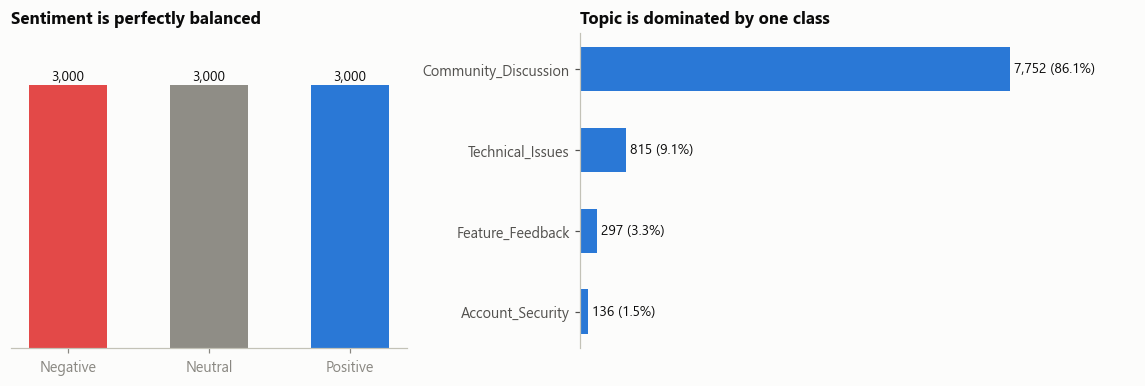

In [3]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.5, 3.6), gridspec_kw={"width_ratios": [1, 1.4]})
sc = raw.sentiment_label.value_counts().reindex(LABELS)
a1.bar(sc.index, sc.values, color=[SENT_COLORS[l] for l in sc.index], width=0.55)
for i, v in enumerate(sc.values):
    a1.text(i, v + 60, f"{v:,}", ha="center", color=INK, fontsize=9)
a1.set_title("Sentiment is perfectly balanced")
a1.set_ylim(0, 3600); a1.grid(axis="x", visible=False); a1.set_yticks([])
a1.spines["left"].set_visible(False)

tc = raw.topic_category.value_counts()
a2.barh(tc.index[::-1], tc.values[::-1], color=S1, height=0.55)
for i, v in enumerate(tc.values[::-1]):
    a2.text(v + 80, i, f"{v:,} ({100*v/len(raw):.1f}%)", va="center", color=INK, fontsize=9)
a2.set_title("Topic is dominated by one class")
a2.set_xlim(0, 10000); a2.grid(axis="y", visible=False); a2.set_xticks([])
a2.spines["bottom"].set_visible(False)
fig.tight_layout()
save(fig, "class_distribution")

**Findings.** 9,000 rows, no missing values. Sentiment is exactly balanced. Only **7,900 texts are unique**: 987 texts appear 2-5 times (2,087 rows), always with identical labels. That is harmless as labels go, but a random split would put copies of the same post on both sides. Section 2 measures how much that inflates scores.

## 2. Leakage check: do duplicates inflate the score?

The same TF-IDF + logistic regression model is evaluated twice on all 9,000 rows: once with ordinary 5-fold cross-validation, and once with folds that keep every copy of a text together.

In [4]:
leak_pipe = Pipeline([("vec", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
                      ("clf", LogisticRegression(max_iter=3000, C=4))])
naive = cross_val_score(leak_pipe, raw.post_text, raw.sentiment_label, scoring="f1_macro", n_jobs=N_JOBS,
                        cv=StratifiedKFold(5, shuffle=True, random_state=SEED))
grouped = cross_val_score(leak_pipe, raw.post_text, raw.sentiment_label, scoring="f1_macro", n_jobs=N_JOBS,
                          groups=raw.dup_key, cv=StratifiedGroupKFold(5, shuffle=True, random_state=SEED))
METRICS["leakage"] = {"naive_cv_f1": round(naive.mean(), 4), "naive_cv_std": round(naive.std(), 4),
                      "grouped_cv_f1": round(grouped.mean(), 4), "grouped_cv_std": round(grouped.std(), 4),
                      "inflation_points": round(100 * (naive.mean() - grouped.mean()), 1)}
print(METRICS["leakage"])

{'naive_cv_f1': np.float64(0.6605), 'naive_cv_std': np.float64(0.0093), 'grouped_cv_f1': np.float64(0.5832), 'grouped_cv_std': np.float64(0.0113), 'inflation_points': np.float64(7.7)}


The ordinary split scores several points higher only because copies leak across folds. **All models below are trained and evaluated on the 7,900 unique texts**, so no post can appear in both training and test data.

## 3. Preprocessing pipeline

`Entropy_nlp_utils.clean_text` applies these steps in order:

| # | Step | Why |
|---|------|-----|
| 1 | Decode literal `\uXXXX` sequences | 100+ posts contain escaped apostrophes (`don\u2019t`) that would split words |
| 2 | Unescape HTML entities | `&amp;` is a rendering artefact, not content |
| 3 | Unicode NFKC + curly quotes to straight | one form per character |
| 4 | Strip wrapping double quotes, collapse `""` | CSV export artefact on ~1,700 posts |
| 5 | URLs to `http`, any `@handle` to `@user` | keep "a link / a mention exists", drop the unique string |
| 6 | Remove `#` but keep the hashtag word | `#ugly` carries sentiment |
| 7 | Cap repeated characters at two (`soooo` to `soo`) | merges spelling variants while keeping emphasis |
| 8 | Collapse whitespace, lowercase | |

Deliberately **not** done: stopword removal (it deletes *not*, *no*, *but*, which flip sentiment; tested in Section 4) and lemmatisation (character n-grams and subword tokenisation already share word stems).

In [5]:
examples = raw.post_text[raw.post_text.str.contains(r"\\u[0-9a-fA-F]{4}|&amp;|^\"|#|(\w)\1{2,}", regex=True)].drop_duplicates().head(6)
display(pd.DataFrame({"raw": examples.values, "cleaned": [nu.clean_text(t) for t in examples]}))

data = raw.drop_duplicates("dup_key").reset_index(drop=True)
data["clean"] = nu.clean_series(data.post_text)
strat = data.sentiment_label + "|" + data.topic_category
train, temp = train_test_split(data, test_size=0.30, stratify=strat, random_state=SEED)
val, test = train_test_split(temp, test_size=0.50, stratify=temp.sentiment_label + "|" + temp.topic_category, random_state=SEED)
splits = {"train": train, "val": val, "test": test}
split_table = pd.DataFrame({k: v.sentiment_label.value_counts().reindex(LABELS) for k, v in splits.items()}).T
split_table["total"] = split_table.sum(axis=1)
display(split_table)
assert not set(train.dup_key) & set(test.dup_key) and not set(train.dup_key) & set(val.dup_key)

tok = AutoTokenizer.from_pretrained(MINILM)
tok_lens = np.array([len(tok(t)["input_ids"]) for t in train.clean])
MAX_LEN = int(min(128, np.ceil(np.percentile(tok_lens, 99.5)) + 4))
METRICS["split"] = {k: len(v) for k, v in splits.items()}
METRICS["split"]["unique_texts"] = len(data)
METRICS["tokens"] = {"p50": int(np.percentile(tok_lens, 50)), "p95": int(np.percentile(tok_lens, 95)),
                     "max": int(tok_lens.max()), "max_len_used": MAX_LEN}
print(METRICS["split"], METRICS["tokens"])

,raw,cleaned
0,"""Sicily may form grand coalition, Italian UDC ...","""sicily may form grand coalition, italian udc ..."
1,@user @user aaaah. Nokia used to make the Best...,@user @user aah. nokia used to make the best p...
2,"""When gaza march out pon the battlefield it's ...",when gaza march out pon the battlefield it's a...
3,"""WLS Quick Look """" Caitlyn Jenner - 1st Public...","wls quick look "" caitlyn jenner - 1st public r..."
4,"""1st game played under Solar Powered floodligh...",1st game played under solar powered floodlight...
5,"""B4 d hood was placed on Yakub's face, he insi...","b4 d hood was placed on yakub's face, he insis..."


sentiment_label,Negative,Neutral,Positive,total
train,1701,1923,1906,5530
val,364,413,408,1185
test,365,412,408,1185


{'train': 5530, 'val': 1185, 'test': 1185, 'unique_texts': 7900} {'p50': 29, 'p95': 39, 'max': 69, 'max_len_used': 50}


**Split.** 70 / 15 / 15 on unique texts, stratified on sentiment and topic together so the rare topics appear in every split. Validation is used for every modelling decision; the test set is used once, in Section 6.

## 4. Preprocessing ablation

Each variant is scored with 5-fold cross-validation on the training split, using the same word + character TF-IDF logistic regression.

In [6]:
cv5 = StratifiedKFold(5, shuffle=True, random_state=SEED)
STOP = [w for w in stopwords.words("english")]
word_vec = lambda **kw: TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True, **kw)
char_vec = lambda: TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), min_df=2, sublinear_tf=True)
lr = lambda C=4: LogisticRegression(max_iter=4000, C=C)

def feats(word=True, char=True, **kw):
    parts = ([("word", word_vec(**kw))] if word else []) + ([("char", char_vec())] if char else [])
    return FeatureUnion(parts) if len(parts) > 1 else parts[0][1]

variants = {
    "No cleaning (raw text)": Pipeline([("f", feats()), ("clf", lr())]),
    "Cleaned (chosen)": Pipeline([("clean", FunctionTransformer(nu.clean_series)), ("f", feats()), ("clf", lr())]),
    "Cleaned + stopword removal": Pipeline([("clean", FunctionTransformer(nu.clean_series)), ("f", FeatureUnion([("word", word_vec(stop_words=STOP)), ("char", char_vec())])), ("clf", lr())]),
    "Cleaned + negation marking": Pipeline([("clean", FunctionTransformer(nu.negation_series)), ("f", feats()), ("clf", lr())]),
    "Cleaned, word n-grams only": Pipeline([("clean", FunctionTransformer(nu.clean_series)), ("f", feats(char=False)), ("clf", lr())]),
    "Cleaned, char n-grams only": Pipeline([("clean", FunctionTransformer(nu.clean_series)), ("f", feats(word=False)), ("clf", lr())]),
}
rows = []
for name, pipe in variants.items():
    s = cross_val_score(pipe, train.post_text, train.sentiment_label, cv=cv5, scoring="f1_macro", n_jobs=N_JOBS)
    rows.append({"variant": name, "cv_macro_f1": s.mean(), "cv_std": s.std()})
ablation = pd.DataFrame(rows)
ablation["delta_vs_chosen"] = ablation.cv_macro_f1 - ablation.loc[ablation.variant == "Cleaned (chosen)", "cv_macro_f1"].item()
METRICS["ablation"] = ablation.round(4).to_dict("records")
ablation.round(4)

,variant,cv_macro_f1,cv_std,delta_vs_chosen
0,No cleaning (raw text),0.5984,0.0097,-0.0042
1,Cleaned (chosen),0.6026,0.0104,0.0000
2,Cleaned + stopword removal,0.5935,0.0166,-0.0091
3,Cleaned + negation marking,0.5984,0.0152,-0.0041
4,"Cleaned, word n-grams only",0.5704,0.0063,-0.0322
5,"Cleaned, char n-grams only",0.6011,0.0128,-0.0015


## 5. Model selection

Candidates, from simplest to strongest:

| Model | Why it is a candidate |
|---|---|
| Majority class | floor: 33.3% macro-F1 would mean nothing was learned |
| Complement Naive Bayes, word TF-IDF | classic fast text baseline, robust with little data |
| Logistic regression, word TF-IDF | linear baseline with interpretable weights |
| Linear SVM / logistic regression, word + char TF-IDF | character n-grams handle misspellings, slang and elongations common in tweets |
| MiniLM sentence embeddings + logistic regression | pretrained semantics without training the encoder |
| Fine-tuned MiniLM (3 seeds) | the encoder itself adapts to tweet sentiment |
| Weighted ensemble | combines models that make different errors |

**Why MiniLM and not a Twitter sentiment model?** Dataset 2's posts match the public SemEval Twitter sentiment benchmark. Models such as `twitter-roberta-base-sentiment` were trained on that benchmark, so they may have already seen these exact test posts. `all-MiniLM-L6-v2` was trained on general sentence pairs, not sentiment labels, so its scores reflect what it learns here. It is also small (22.7M parameters), so it fine-tunes on a CPU in minutes.

Classical models are tuned with 5-fold cross-validation on the training split, then scored on validation.

In [7]:
def timed_predict(model, X):
    t = time.perf_counter(); p = model.predict(X); return p, 1000 * (time.perf_counter() - t) / len(X)

def pkl_kb(obj):
    return len(pickle.dumps(obj)) / 1024

clean_step = lambda: ("clean", FunctionTransformer(nu.clean_series))
grid_specs = {
    "Complement NB (word)": (Pipeline([clean_step(), ("f", word_vec()), ("clf", ComplementNB())]), {"clf__alpha": [0.1, 0.3, 1.0]}),
    "LogReg (word)": (Pipeline([clean_step(), ("f", word_vec()), ("clf", lr())]), {"clf__C": [1, 4, 16]}),
    "Linear SVM (word+char)": (Pipeline([clean_step(), ("f", feats()), ("clf", LinearSVC())]), {"clf__C": [0.1, 0.3, 1.0]}),
    "LogReg (word+char)": (Pipeline([clean_step(), ("f", feats()), ("clf", lr())]), {"clf__C": [1, 2, 4, 8]}),
}
results, fitted, val_pred, test_pred, val_proba, test_proba = [], {}, {}, {}, {}, {}

dummy = DummyClassifier(strategy="most_frequent").fit(train.post_text, train.sentiment_label)
for name, m in [("Majority class", dummy)]:
    val_pred[name], test_pred[name] = m.predict(val.post_text), m.predict(test.post_text)
    results.append({"model": name, "cv_f1": np.nan, "cv_std": np.nan, "best_params": "-", "fit_s": 0.0,
                    "ms_per_post": 0.0, "size_kb": pkl_kb(m)})

for name, (pipe, grid) in grid_specs.items():
    gs = GridSearchCV(pipe, grid, cv=cv5, scoring="f1_macro", n_jobs=N_JOBS, refit=True)
    t = time.perf_counter(); gs.fit(train.post_text, train.sentiment_label); fit_s = time.perf_counter() - t
    best = gs.best_estimator_
    fitted[name] = best
    val_pred[name], ms = timed_predict(best, val.post_text)
    test_pred[name] = best.predict(test.post_text)
    if hasattr(best, "predict_proba"):
        val_proba[name], test_proba[name] = best.predict_proba(val.post_text), best.predict_proba(test.post_text)
    results.append({"model": name, "cv_f1": gs.best_score_, "cv_std": gs.cv_results_["std_test_score"][gs.best_index_],
                    "best_params": str(gs.best_params_), "fit_s": fit_s, "ms_per_post": ms, "size_kb": pkl_kb(best)})
    print(f"{name:26s} CV {gs.best_score_:.4f} | {gs.best_params_}")

Complement NB (word)       CV 0.5676 | {'clf__alpha': 1.0}
LogReg (word)              CV 0.5734 | {'clf__C': 1}
Linear SVM (word+char)     CV 0.6042 | {'clf__C': 0.1}
LogReg (word+char)         CV 0.6049 | {'clf__C': 2}


In [8]:
embedder = SentenceTransformer(MINILM, device="cpu")
ENCODER_KB = sum(p.numel() for p in embedder.parameters()) * 4 / 1024
t = time.perf_counter()
EMB = {k: embedder.encode(v.clean.tolist(), batch_size=256, normalize_embeddings=True, show_progress_bar=False) for k, v in splits.items()}
embed_s = time.perf_counter() - t
gs = GridSearchCV(LogisticRegression(max_iter=4000), {"C": [0.5, 1, 2, 4, 8]}, cv=cv5, scoring="f1_macro", n_jobs=N_JOBS)
t = time.perf_counter(); gs.fit(EMB["train"], train.sentiment_label); fit_s = time.perf_counter() - t
emb_lr = gs.best_estimator_
name = "MiniLM embeddings + LogReg"
fitted[name] = emb_lr
t = time.perf_counter()
val_pred[name] = emb_lr.predict(embedder.encode(val.clean.tolist(), batch_size=256, normalize_embeddings=True, show_progress_bar=False))
ms = 1000 * (time.perf_counter() - t) / len(val)
test_pred[name] = emb_lr.predict(EMB["test"])
val_proba[name], test_proba[name] = emb_lr.predict_proba(EMB["val"]), emb_lr.predict_proba(EMB["test"])
results.append({"model": name, "cv_f1": gs.best_score_, "cv_std": gs.cv_results_["std_test_score"][gs.best_index_],
                "best_params": str(gs.best_params_), "fit_s": fit_s + embed_s * len(train) / len(data), "ms_per_post": ms,
                "size_kb": pkl_kb(emb_lr) + ENCODER_KB})
print(f"{name} CV {gs.best_score_:.4f} | {gs.best_params_}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4994.84it/s]


MiniLM embeddings + LogReg CV 0.6509 | {'C': 0.5}


### Fine-tuning MiniLM

A classification head is added on top of MiniLM and the whole network is trained with AdamW (learning rate 5e-5, weight decay 0.01, linear warm-up over 10% of steps then decay), batch size 32, dynamic padding, for up to four epochs. After each epoch the model is scored on validation; the best epoch is kept and training stops once validation macro-F1 fails to improve for two epochs. Three random seeds are trained to measure run-to-run variation, and their probabilities are averaged.

In [9]:
def finetune(seed, lr_=5e-5, bs=32, epochs=MAX_EPOCHS, patience=2):
    set_seed(seed)
    tk = AutoTokenizer.from_pretrained(MINILM)
    model = AutoModelForSequenceClassification.from_pretrained(MINILM, num_labels=len(LABELS),
                                                               id2label=dict(enumerate(LABELS)), label2id={l: i for i, l in enumerate(LABELS)})
    X, y = train.clean.tolist(), train.sentiment_label.map(LABELS.index).to_numpy()
    steps = epochs * int(np.ceil(len(X) / bs))
    opt = torch.optim.AdamW(model.parameters(), lr=lr_, weight_decay=0.01)
    sched = get_linear_schedule_with_warmup(opt, int(0.1 * steps), steps)
    rng = np.random.default_rng(seed)
    best_f1, best_state, bad, history = -1, None, 0, []
    for ep in range(1, epochs + 1):
        model.train(); t = time.perf_counter(); losses = []
        order = rng.permutation(len(X))
        for i in range(0, len(X), bs):
            b = order[i:i + bs]
            enc = tk([X[j] for j in b], padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt")
            out = model(**enc, labels=torch.tensor(y[b]))
            out.loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step(); opt.zero_grad()
            losses.append(out.loss.item())
        pv = nu.transformer_proba(model, tk, val.clean.tolist(), MAX_LEN)
        yv = val.sentiment_label.map(LABELS.index).to_numpy()
        vf1 = f1_score(yv, pv.argmax(1), average="macro")
        vloss = float(-np.mean(np.log(pv[np.arange(len(yv)), yv] + 1e-12)))
        history.append({"seed": seed, "epoch": ep, "train_loss": float(np.mean(losses)), "val_loss": vloss,
                        "val_macro_f1": vf1, "epoch_s": time.perf_counter() - t})
        print(f"  seed {seed} epoch {ep}: train loss {np.mean(losses):.4f} | val loss {vloss:.4f} | val macro-F1 {vf1:.4f} | {time.perf_counter()-t:.0f}s")
        if vf1 > best_f1:
            best_f1, bad = vf1, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                break
    model.load_state_dict(best_state)
    return model, tk, history

FT = {}
histories = []
t_all = time.perf_counter()
for s in SEEDS:
    model, tk, hist = finetune(s)
    histories += hist
    FT[s] = {"model": model, "tok": tk,
             "val": nu.transformer_proba(model, tk, val.clean.tolist(), MAX_LEN),
             "test": nu.transformer_proba(model, tk, test.clean.tolist(), MAX_LEN),
             "best_epoch": max(hist, key=lambda h: h["val_macro_f1"])["epoch"]}
ft_train_s = time.perf_counter() - t_all
hist_df = pd.DataFrame(histories)
METRICS["finetune_history"] = hist_df.round(4).to_dict("records")
hist_df.round(4)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4385.03it/s]


  seed 42 epoch 1: train loss 0.9054 | val loss 0.7171 | val macro-F1 0.6848 | 139s
  seed 42 epoch 2: train loss 0.6259 | val loss 0.7072 | val macro-F1 0.7017 | 137s
  seed 42 epoch 3: train loss 0.4897 | val loss 0.7498 | val macro-F1 0.6942 | 136s
  seed 42 epoch 4: train loss 0.4004 | val loss 0.7895 | val macro-F1 0.6868 | 135s


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2927.83it/s]


  seed 7 epoch 1: train loss 0.9033 | val loss 0.7157 | val macro-F1 0.6851 | 138s
  seed 7 epoch 2: train loss 0.6336 | val loss 0.7196 | val macro-F1 0.6841 | 134s
  seed 7 epoch 3: train loss 0.5014 | val loss 0.7590 | val macro-F1 0.6977 | 135s
  seed 7 epoch 4: train loss 0.4110 | val loss 0.7957 | val macro-F1 0.6864 | 137s


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2488.21it/s]


  seed 1234 epoch 1: train loss 0.9166 | val loss 0.7393 | val macro-F1 0.6735 | 178s
  seed 1234 epoch 2: train loss 0.6267 | val loss 0.7178 | val macro-F1 0.6881 | 161s
  seed 1234 epoch 3: train loss 0.4947 | val loss 0.7500 | val macro-F1 0.6857 | 164s
  seed 1234 epoch 4: train loss 0.4055 | val loss 0.7948 | val macro-F1 0.6822 | 166s


,seed,epoch,train_loss,val_loss,val_macro_f1,epoch_s
0,42,1,0.9054,0.7171,0.6848,138.9793
1,42,2,0.6259,0.7072,0.7017,136.5465
2,42,3,0.4897,0.7498,0.6942,136.0172
3,42,4,0.4004,0.7895,0.6868,135.0336
4,7,1,0.9033,0.7157,0.6851,137.8970
5,7,2,0.6336,0.7196,0.6841,134.1709
6,7,3,0.5014,0.7590,0.6977,134.6621
7,7,4,0.4110,0.7957,0.6864,137.1573
8,1234,1,0.9166,0.7393,0.6735,178.2773
9,1234,2,0.6267,0.7178,0.6881,161.4063


In [10]:
yv = val.sentiment_label.to_numpy(); yt = test.sentiment_label.to_numpy()
seed_val_f1 = {s: f1_score(yv, np.array(LABELS)[FT[s]["val"].argmax(1)], average="macro") for s in SEEDS}
best_seed = max(seed_val_f1, key=seed_val_f1.get)
ft_val_avg = np.mean([FT[s]["val"] for s in SEEDS], axis=0)
ft_test_avg = np.mean([FT[s]["test"] for s in SEEDS], axis=0)

t = time.perf_counter()
_ = nu.transformer_proba(FT[best_seed]["model"], FT[best_seed]["tok"], val.clean.tolist(), MAX_LEN)
ft_ms = 1000 * (time.perf_counter() - t) / len(val)

name = f"Fine-tuned MiniLM (best seed {best_seed})"
val_proba[name], test_proba[name] = FT[best_seed]["val"], FT[best_seed]["test"]
results.append({"model": name, "cv_f1": np.mean(list(seed_val_f1.values())), "cv_std": np.std(list(seed_val_f1.values())),
                "best_params": f"lr 5e-5, best epoch {FT[best_seed]['best_epoch']}", "fit_s": ft_train_s / len(SEEDS),
                "ms_per_post": ft_ms, "size_kb": ENCODER_KB})
name = f"Fine-tuned MiniLM ({len(SEEDS)}-seed average)"
val_proba[name], test_proba[name] = ft_val_avg, ft_test_avg
results.append({"model": name, "cv_f1": np.nan, "cv_std": np.nan, "best_params": f"seeds {SEEDS}",
                "fit_s": ft_train_s, "ms_per_post": ft_ms * len(SEEDS), "size_kb": ENCODER_KB * len(SEEDS)})
for n in list(val_proba):
    if n.startswith("Fine-tuned"):
        val_pred[n] = np.array(LABELS)[val_proba[n].argmax(1)]
        test_pred[n] = np.array(LABELS)[test_proba[n].argmax(1)]
METRICS["finetune"] = {"seed_val_f1": {str(k): round(v, 4) for k, v in seed_val_f1.items()}, "best_seed": best_seed,
                       "seed_std": round(float(np.std(list(seed_val_f1.values()))), 4), "train_seconds_total": round(ft_train_s)}
print(METRICS["finetune"])

{'seed_val_f1': {'42': 0.7017, '7': 0.6977, '1234': 0.6881}, 'best_seed': 42, 'seed_std': 0.0057, 'train_seconds_total': 1798}


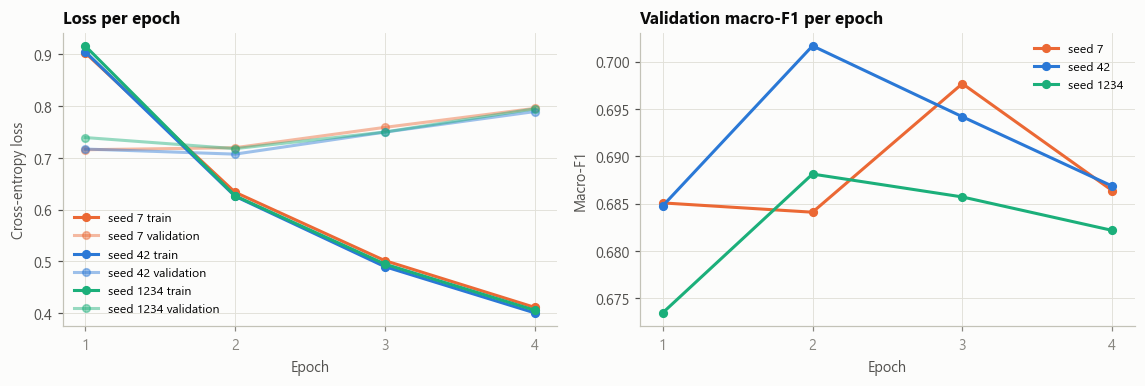

In [11]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.5, 3.6))
seed_colors = dict(zip(SEEDS, [S1, S2, "#1baf7a"]))
for s, g in hist_df.groupby("seed"):
    a1.plot(g.epoch, g.train_loss, color=seed_colors[s], lw=2, marker="o", ms=5, label=f"seed {s} train")
    a1.plot(g.epoch, g.val_loss, color=seed_colors[s], lw=2, marker="o", ms=5, alpha=0.45, label=f"seed {s} validation")
    a2.plot(g.epoch, g.val_macro_f1, color=seed_colors[s], lw=2, marker="o", ms=5, label=f"seed {s}")
a1.set_title("Loss per epoch"); a1.set_xlabel("Epoch"); a1.set_ylabel("Cross-entropy loss")
a2.set_title("Validation macro-F1 per epoch"); a2.set_xlabel("Epoch"); a2.set_ylabel("Macro-F1")
for a in (a1, a2):
    a.set_xticks(sorted(hist_df.epoch.unique())); a.legend(fontsize=8)
fig.tight_layout()
save(fig, "training_curves")

### Weighted ensemble

The three probability-producing model families make different kinds of errors: TF-IDF keys on surface words, frozen embeddings on general meaning, the fine-tuned model on learned tone. Their probabilities are averaged with weights chosen on validation (grid over weights in steps of 0.05 summing to 1).

In [12]:
parts = {"tfidf_logreg": "LogReg (word+char)", "embedding_logreg": "MiniLM embeddings + LogReg",
         "minilm_finetuned": f"Fine-tuned MiniLM ({len(SEEDS)}-seed average)"}
best_w, best_f = None, -1
steps = np.round(np.arange(0, 1.0001, 0.05), 2)
for w1 in steps:
    for w2 in steps:
        w3 = round(1 - w1 - w2, 2)
        if w3 < -1e-9:
            continue
        p = w1 * val_proba[parts["tfidf_logreg"]] + w2 * val_proba[parts["embedding_logreg"]] + w3 * val_proba[parts["minilm_finetuned"]]
        f = f1_score(yv, np.array(LABELS)[p.argmax(1)], average="macro")
        if f > best_f + 1e-9:
            best_f, best_w = f, {"tfidf_logreg": float(w1), "embedding_logreg": float(w2), "minilm_finetuned": float(w3)}
ens = lambda probs: sum(best_w[k] * probs[parts[k]] for k in parts)
name = "Weighted ensemble"
val_proba[name], test_proba[name] = ens(val_proba), ens(test_proba)
val_pred[name] = np.array(LABELS)[val_proba[name].argmax(1)]
test_pred[name] = np.array(LABELS)[test_proba[name].argmax(1)]
results.append({"model": name, "cv_f1": np.nan, "cv_std": np.nan, "best_params": json.dumps(best_w),
                "fit_s": np.nan, "ms_per_post": np.nan, "size_kb": np.nan})
METRICS["ensemble_weights"] = best_w
print("weights:", best_w, "| val macro-F1:", round(best_f, 4))

weights: {'tfidf_logreg': 0.25, 'embedding_logreg': 0.2, 'minilm_finetuned': 0.55} | val macro-F1: 0.7111


In [13]:
res = pd.DataFrame(results).set_index("model")
res["val_accuracy"] = [accuracy_score(yv, val_pred[m]) for m in res.index]
res["val_macro_f1"] = [f1_score(yv, val_pred[m], average="macro") for m in res.index]
res.loc["Weighted ensemble", ["fit_s", "ms_per_post", "size_kb"]] = [
    res.loc[[parts["tfidf_logreg"], parts["embedding_logreg"], parts["minilm_finetuned"]], "fit_s"].sum(),
    res.loc[[parts["tfidf_logreg"], parts["embedding_logreg"], parts["minilm_finetuned"]], "ms_per_post"].sum(),
    res.loc[[parts["tfidf_logreg"], parts["embedding_logreg"], parts["minilm_finetuned"]], "size_kb"].sum()]
SELECTED = res.val_macro_f1.idxmax()
BEST_CLASSICAL = res.loc[[m for m in grid_specs]].val_macro_f1.idxmax()
print("Selected on validation:", SELECTED, "| best classical:", BEST_CLASSICAL)
display(res[["cv_f1", "cv_std", "val_accuracy", "val_macro_f1", "fit_s", "ms_per_post", "size_kb", "best_params"]].round(4))

Selected on validation: Weighted ensemble | best classical: Linear SVM (word+char)


,cv_f1,cv_std,val_accuracy,val_macro_f1,fit_s,ms_per_post,size_kb,best_params
model,,,,,,,,
Majority class,NaN,NaN,0.3485,0.1723,0.0000,0.0000,0.4736,-
Complement NB (word),0.5676,0.0104,0.5671,0.5629,2.0750,0.1539,1146.4746,{'clf__alpha': 1.0}
LogReg (word),0.5734,0.0088,0.5620,0.5624,4.1658,0.0353,676.1689,{'clf__C': 1}
Linear SVM (word+char),0.6042,0.0102,0.6051,0.6061,6.6005,0.1478,2623.8867,{'clf__C': 0.1}
LogReg (word+char),0.6049,0.0108,0.5873,0.5888,22.3442,0.3239,2623.9814,{'clf__C': 2}
MiniLM embeddings + LogReg,0.6509,0.0119,0.6489,0.6502,25.5468,4.5265,88733.2275,{'C': 0.5}
Fine-tuned MiniLM (best seed 42),0.6958,0.0057,0.7030,0.7017,599.1890,5.7013,88723.5000,"lr 5e-5, best epoch 2"
Fine-tuned MiniLM (3-seed average),NaN,NaN,0.6937,0.6955,1797.5671,17.1038,266170.5000,"seeds [42, 7, 1234]"
Weighted ensemble,NaN,NaN,0.7097,0.7111,1845.4581,21.9542,357527.7090,"{""tfidf_logreg"": 0.25, ""embedding_logreg"": 0.2..."


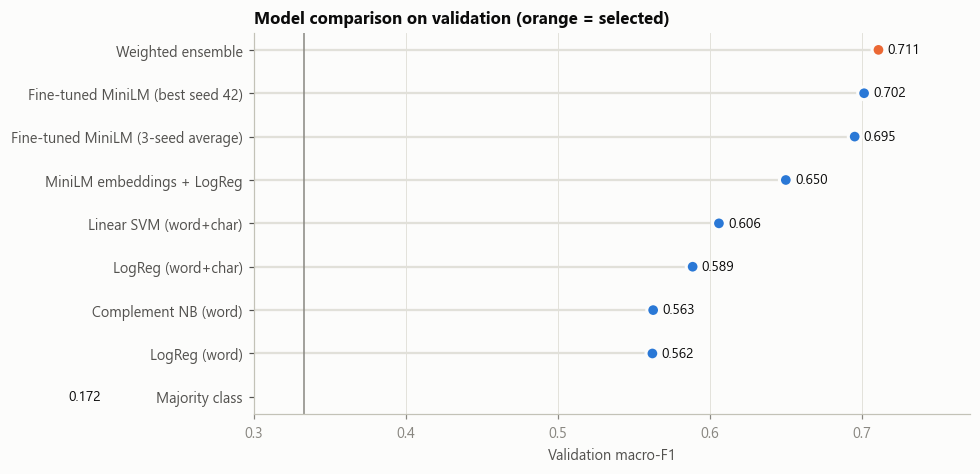

In [14]:
order = res.val_macro_f1.sort_values().index
fig, ax = plt.subplots(figsize=(9, 4.4))
y = np.arange(len(order))
colors = [S2 if m == SELECTED else S1 for m in order]
ax.scatter(res.loc[order, "val_macro_f1"], y, s=70, color=colors, edgecolor=SURF, linewidth=2, zorder=3)
ax.hlines(y, 0.3, res.loc[order, "val_macro_f1"], color=GRID, lw=1.5, zorder=1)
for yi, m in zip(y, order):
    ax.text(res.loc[m, "val_macro_f1"] + 0.006, yi, f"{res.loc[m, 'val_macro_f1']:.3f}", va="center", fontsize=9, color=INK)
ax.set_yticks(y, order)
ax.axvline(1/3, color=MUTED, lw=1)
ax.set_xlim(0.3, res.val_macro_f1.max() + 0.06)
ax.set_xlabel("Validation macro-F1")
ax.set_title("Model comparison on validation (orange = selected)")
ax.grid(axis="y", visible=False)
fig.tight_layout()
save(fig, "model_comparison")

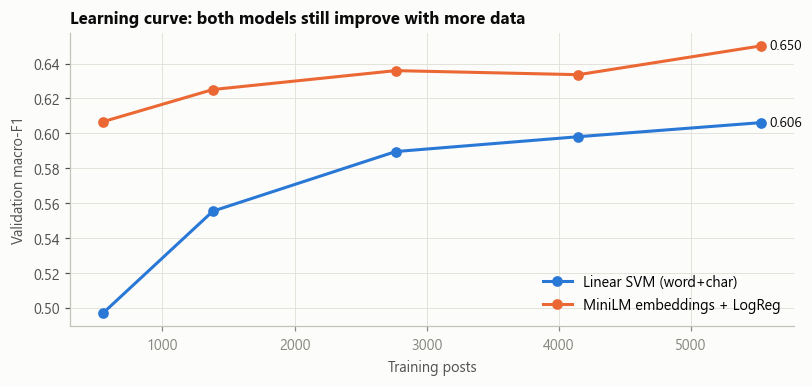

,fraction,n,Linear SVM (word+char),MiniLM embeddings + LogReg
0,0.10,553,0.4971,0.6067
1,0.25,1382,0.5554,0.6251
2,0.50,2765,0.5896,0.6360
3,0.75,4148,0.5981,0.6336
4,1.00,5530,0.6061,0.6502


In [15]:
fractions = [0.1, 0.25, 0.5, 0.75, 1.0]
lc = []
for frac in fractions:
    sub = train.sample(frac=frac, random_state=SEED) if frac < 1 else train
    idx = train.index.get_indexer(sub.index)
    m1 = clone(fitted[BEST_CLASSICAL]).fit(sub.post_text, sub.sentiment_label)
    m2 = clone(emb_lr).fit(EMB["train"][idx], sub.sentiment_label)
    lc.append({"fraction": frac, "n": len(sub),
               BEST_CLASSICAL: f1_score(yv, m1.predict(val.post_text), average="macro"),
               "MiniLM embeddings + LogReg": f1_score(yv, m2.predict(EMB["val"]), average="macro")})
lc = pd.DataFrame(lc)
METRICS["learning_curve"] = lc.round(4).to_dict("records")
fig, ax = plt.subplots(figsize=(7.5, 3.6))
for col, c in [(BEST_CLASSICAL, S1), ("MiniLM embeddings + LogReg", S2)]:
    ax.plot(lc.n, lc[col], color=c, lw=2, marker="o", ms=6, label=col)
    ax.text(lc.n.iloc[-1] + 60, lc[col].iloc[-1], f"{lc[col].iloc[-1]:.3f}", va="center", fontsize=9, color=INK)
ax.set_xlabel("Training posts"); ax.set_ylabel("Validation macro-F1")
ax.set_title("Learning curve: both models still improve with more data")
ax.legend(loc="lower right")
fig.tight_layout()
save(fig, "learning_curve")
lc.round(4)

## 6. Final evaluation on the held-out test set

The selected model was chosen on validation only; this is its first and only contact with the test set. For transparency every candidate's test score is shown too.

In [16]:
res["test_accuracy"] = [accuracy_score(yt, test_pred[m]) for m in res.index]
res["test_macro_f1"] = [f1_score(yt, test_pred[m], average="macro") for m in res.index]
res["test_roc_auc"] = [roc_auc_score(yt, test_proba[m], multi_class="ovr", labels=LABELS) if m in test_proba else np.nan for m in res.index]
res.round(4).to_csv(OUT / "Entropy_r2_model_comparison.csv")
METRICS["models"] = res.reset_index().round(4).replace({np.nan: None}).to_dict("records")

final_pred, final_proba = test_pred[SELECTED], test_proba[SELECTED]
p, r, f, s = precision_recall_fscore_support(yt, final_pred, labels=LABELS)
per_class = pd.DataFrame({"precision": p, "recall": r, "f1": f, "support": s}, index=LABELS)
report = classification_report(yt, final_pred, labels=LABELS, digits=4, output_dict=True)
pd.DataFrame(report).T.round(4).to_csv(OUT / "Entropy_r2_classification_report.csv")

rng = np.random.default_rng(SEED)
boot, boot_delta, boot_acc = [], [], []
base_pred = test_pred[BEST_CLASSICAL]
for _ in range(N_BOOT):
    i = rng.integers(0, len(yt), len(yt))
    fs = f1_score(yt[i], final_pred[i], average="macro")
    boot.append(fs); boot_acc.append(accuracy_score(yt[i], final_pred[i]))
    boot_delta.append(fs - f1_score(yt[i], base_pred[i], average="macro"))
ci = np.percentile(boot, [2.5, 97.5]); ci_acc = np.percentile(boot_acc, [2.5, 97.5]); ci_d = np.percentile(boot_delta, [2.5, 97.5])
right_sel, right_base = final_pred == yt, base_pred == yt
b, c = int((right_sel & ~right_base).sum()), int((~right_sel & right_base).sum())
mcnemar_p = stats.binomtest(min(b, c), b + c, 0.5).pvalue if b + c else 1.0

METRICS["final"] = {
    "selected_model": SELECTED, "best_classical": BEST_CLASSICAL, "n_test": int(len(yt)),
    "accuracy": round(accuracy_score(yt, final_pred), 4), "macro_f1": round(f1_score(yt, final_pred, average="macro"), 4),
    "weighted_f1": round(f1_score(yt, final_pred, average="weighted"), 4),
    "macro_precision": round(float(p.mean()), 4), "macro_recall": round(float(r.mean()), 4),
    "roc_auc_ovr": round(roc_auc_score(yt, final_proba, multi_class="ovr", labels=LABELS), 4),
    "macro_f1_ci95": [round(x, 4) for x in ci], "accuracy_ci95": [round(x, 4) for x in ci_acc],
    "delta_vs_best_classical": round(f1_score(yt, final_pred, average="macro") - f1_score(yt, base_pred, average="macro"), 4),
    "delta_ci95": [round(x, 4) for x in ci_d], "mcnemar_b": b, "mcnemar_c": c, "mcnemar_p": float(mcnemar_p),
    "per_class": per_class.round(4).to_dict("index"),
}
print(json.dumps(METRICS["final"], indent=2))
per_class.round(4)

{
  "selected_model": "Weighted ensemble",
  "best_classical": "Linear SVM (word+char)",
  "n_test": 1185,
  "accuracy": 0.7173,
  "macro_f1": 0.7178,
  "weighted_f1": 0.7158,
  "macro_precision": 0.7167,
  "macro_recall": 0.7197,
  "roc_auc_ovr": 0.8805,
  "macro_f1_ci95": [
    0.6913,
    0.7414
  ],
  "accuracy_ci95": [
    0.6903,
    0.7418
  ],
  "delta_vs_best_classical": 0.0935,
  "delta_ci95": [
    0.0655,
    0.1243
  ],
  "mcnemar_b": 208,
  "mcnemar_c": 98,
  "mcnemar_p": 3.00637005433363e-10,
  "per_class": {
    "Negative": {
      "precision": 0.7527,
      "recall": 0.7753,
      "f1": 0.7638,
      "support": 365
    },
    "Neutral": {
      "precision": 0.6545,
      "recall": 0.6117,
      "f1": 0.6324,
      "support": 412
    },
    "Positive": {
      "precision": 0.7429,
      "recall": 0.7721,
      "f1": 0.7572,
      "support": 408
    }
  }
}


,precision,recall,f1,support
Negative,0.7527,0.7753,0.7638,365
Neutral,0.6545,0.6117,0.6324,412
Positive,0.7429,0.7721,0.7572,408


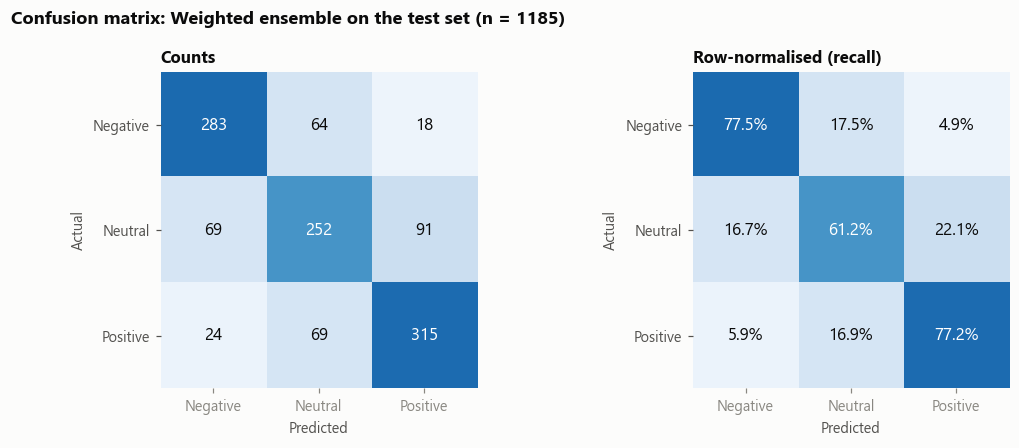

In [17]:
cm = confusion_matrix(yt, final_pred, labels=LABELS)
cmn = cm / cm.sum(axis=1, keepdims=True)
METRICS["final"]["confusion_matrix"] = cm.tolist()
fig, axes = plt.subplots(1, 2, figsize=(10, 4.1))
for ax, mat, title, fmt in [(axes[0], cm, "Counts", "{:d}"), (axes[1], cmn, "Row-normalised (recall)", "{:.1%}")]:
    im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, fmt.format(mat[i, j]), ha="center", va="center", fontsize=11,
                    color="white" if cmn[i, j] > 0.5 else INK)
    ax.set_xticks(range(3), LABELS); ax.set_yticks(range(3), LABELS)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title)
    ax.grid(False)
    for sp in ax.spines.values():
        sp.set_visible(False)
fig.suptitle(f"Confusion matrix: {SELECTED} on the test set (n = {len(yt)})", x=0.01, ha="left", fontsize=12, fontweight="bold", color=INK)
fig.tight_layout()
save(fig, "confusion_matrix")

## 7. Error analysis

Where does the selected model fail, and why? Errors are broken down by confusion pair, by properties of the post, and by inspecting the most confident mistakes.

In [18]:
ea = test[["text_id", "post_text", "clean", "sentiment_label", "topic_category"]].copy()
ea["pred"] = final_pred
ea["confidence"] = final_proba.max(1)
ea["correct"] = ea.pred == ea.sentiment_label
wc = ea.clean.str.split().str.len()
slices = {
    "All test posts": np.ones(len(ea), bool),
    "Short (<= 12 words)": wc <= 12, "Medium (13-20 words)": (wc > 12) & (wc <= 20), "Long (> 20 words)": wc > 20,
    "Contains @user": ea.clean.str.contains("@user", regex=False),
    "Contains a hashtag": ea.post_text.str.contains("#", regex=False),
    "Contains negation": ea.clean.str.contains(r"\b(?:not|no|never|nothing|cannot|\w+n't|dont|cant|wont)\b"),
    "Contains contrast (but / though)": ea.clean.str.contains(r"\b(?:but|though|although|however|yet)\b"),
    "Contains a question mark": ea.clean.str.contains("?", regex=False),
    "Contains an exclamation mark": ea.clean.str.contains("!", regex=False),
    "Contains digits (scores, dates)": ea.clean.str.contains(r"\d"),
}
sl = pd.DataFrame([{"slice": k, "n": int(v.sum()), "error_rate": 1 - ea.correct[v].mean()} for k, v in slices.items()])
pairs = (ea[~ea.correct].groupby(["sentiment_label", "pred"]).size().rename("errors").reset_index()
         .assign(share=lambda d: d.errors / d.errors.sum()).sort_values("errors", ascending=False))
conf_bins = pd.cut(ea.confidence, [0, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
calib = ea.groupby(conf_bins, observed=True).agg(n=("correct", "size"), accuracy=("correct", "mean"), mean_conf=("confidence", "mean")).reset_index()
calib["confidence"] = calib.confidence.astype(str)
METRICS["errors"] = {"n_errors": int((~ea.correct).sum()), "pairs": pairs.round(4).to_dict("records"),
                     "slices": sl.round(4).to_dict("records"), "calibration": calib.round(4).to_dict("records")}
display(pairs.round(3)); display(sl.round(3)); display(calib.round(3))

,sentiment_label,pred,errors,share
3,Neutral,Positive,91,0.272
2,Neutral,Negative,69,0.206
5,Positive,Neutral,69,0.206
0,Negative,Neutral,64,0.191
4,Positive,Negative,24,0.072
1,Negative,Positive,18,0.054


,slice,n,error_rate
0,All test posts,1185,0.283
1,Short (<= 12 words),117,0.316
2,Medium (13-20 words),559,0.259
3,Long (> 20 words),509,0.301
4,Contains @user,342,0.275
5,Contains a hashtag,194,0.227
6,Contains negation,273,0.256
7,Contains contrast (but / though),143,0.308
8,Contains a question mark,153,0.294
9,Contains an exclamation mark,208,0.255


,confidence,n,accuracy,mean_conf
0,"(0.0, 0.5]",147,0.415,0.451
1,"(0.5, 0.6]",241,0.577,0.551
2,"(0.6, 0.7]",270,0.733,0.650
3,"(0.7, 0.8]",290,0.807,0.747
4,"(0.8, 0.9]",185,0.897,0.847
5,"(0.9, 1.0]",52,1.000,0.925


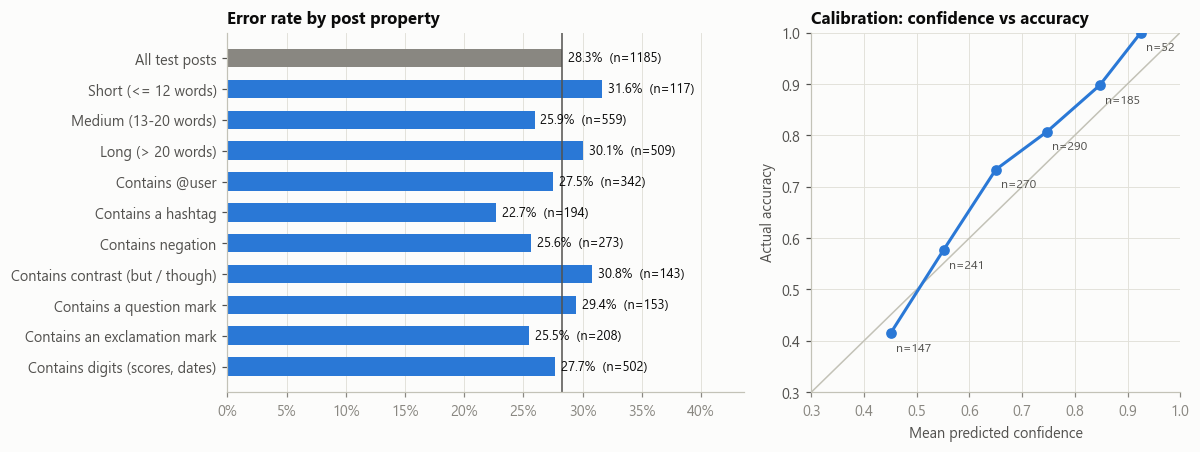

In [19]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [1.4, 1]})
s2 = sl.iloc[::-1]
overall = sl.error_rate.iloc[0]
a1.barh(s2.slice, s2.error_rate, color=[MUTED if x == "All test posts" else S1 for x in s2.slice], height=0.6)
for i, (er, n) in enumerate(zip(s2.error_rate, s2.n)):
    a1.text(er + 0.005, i, f"{er:.1%}  (n={n})", va="center", fontsize=8.5, color=INK)
a1.axvline(overall, color=INK2, lw=1)
a1.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
a1.set_xlim(0, s2.error_rate.max() + 0.12)
a1.set_title("Error rate by post property"); a1.grid(axis="y", visible=False)

a2.plot([0.3, 1], [0.3, 1], color=BASE, lw=1)
a2.plot(calib.mean_conf, calib.accuracy, color=S1, lw=2, marker="o", ms=6)
for _, row in calib.iterrows():
    a2.text(row.mean_conf + 0.01, row.accuracy - 0.035, f"n={row.n}", fontsize=8, color=INK2)
a2.set_xlim(0.3, 1); a2.set_ylim(0.3, 1)
a2.set_xlabel("Mean predicted confidence"); a2.set_ylabel("Actual accuracy")
a2.set_title("Calibration: confidence vs accuracy")
fig.tight_layout()
save(fig, "error_slices")

In [20]:
pd.set_option("display.max_colwidth", 140)
confident_errors = ea[~ea.correct].sort_values("confidence", ascending=False)
METRICS["errors"]["confident_errors"] = confident_errors.head(15)[["text_id", "post_text", "sentiment_label", "pred", "confidence"]].round(3).to_dict("records")
display(confident_errors.head(15)[["text_id", "post_text", "sentiment_label", "pred", "confidence"]])
neutral_misses = ea[(ea.sentiment_label == "Neutral") & ~ea.correct].sample(8, random_state=SEED)
display(neutral_misses[["post_text", "pred", "confidence"]])

,text_id,post_text,sentiment_label,pred,confidence
3936,TXT_04183,"@user @user Sarah Palin, other women you disagree with may still be quite bright.Hillary may be intelligent, just wrong.",Neutral,Negative,0.883011
3317,TXT_03481,Alright ladies and (yes) gents. Our poll is here! You may know these two best from both Thor movies AND the Avengers (among others).,Neutral,Positive,0.877890
2366,TXT_02459,@user @user Yakub got bad unfair sentence due to 3rd rate prosecutor not telling court about his crucial cooperation.,Neutral,Negative,0.873246
6482,TXT_07186,"@user i could pick up my dog, my 2nd cousin and david beckham and still get top 3 at that event, pls win it",Neutral,Positive,0.871305
1852,TXT_01917,"How in the HECK am I expected to go to class tomorrow, or even LIVE, after Beyonce has just killed me like this??????",Neutral,Negative,0.867592
4440,TXT_04747,I'm selling a lawn ticket for Jason Aldean this coming Friday! DM me if you're interested!,Neutral,Positive,0.866894
1287,TXT_01322,I just bought two tickets for the Sacramento Kings season opener on Monday! HYPED.,Neutral,Positive,0.854640
6130,TXT_06750,#YakubDebate have you seen the long bearded Yakub off late. #presstitutes won't show the radicalised man.,Neutral,Negative,0.849488
3733,TXT_03954,Serbian President to Visit Pope Francis on Friday: Serbian President Tomislav Nikolic will meet with Pope Fran...,Positive,Neutral,0.845356
1637,TXT_01691,Racist Mad Libs: Islam is _______ with _____,Neutral,Negative,0.844947


,post_text,pred,confidence
6550,So I asked a diehard FSU fan about the game against Dook on Sat & they are kinda worried about Coach Cut & his Coastal division leading ...,Negative,0.804569
7305,These PAUL McCartney tix are burning a hole in my pocket. Want em? Call 313-298-1043 after the 2nd Paul/Beatles song. It WILL happen.,Negative,0.457719
2407,Sat here watching Celebrity Juice again 3rd time today with my mum.,Positive,0.647957
3936,"@user @user Sarah Palin, other women you disagree with may still be quite bright.Hillary may be intelligent, just wrong.",Negative,0.883011
5059,@user you a Pats fan yet after seeing the best in the business on Sunday?,Positive,0.773259
541,How To Dress Well plays Santos Party House on October 8th with o f f Love and Warm Ghost!,Positive,0.544171
2739,@user which 3rd place Big Brother Contestant deserved to win their respective season the most?,Positive,0.463255
6682,omg i bought sam smith tickets way back in feb and forgot all about it until my friend texted me that it's tomorrow,Positive,0.627476


In [21]:
wm = fitted["LogReg (word)"]
vocab = np.array(wm.named_steps["f"].get_feature_names_out())
coef = wm.named_steps["clf"].coef_
top_terms = {lab: list(vocab[np.argsort(-coef[i])[:12]]) for i, lab in enumerate(wm.named_steps["clf"].classes_)}
METRICS["top_terms"] = top_terms
pd.DataFrame(top_terms)

,Negative,Neutral,Positive
0,fuck,gucci,love
1,not,at,happy
2,no,do you,good
3,sad,meet,best
4,don,hold,great
5,shit,in,excited
6,why,nirvana,amazing
7,bad,days,thanks
8,hate,zayn,perfect
9,worst,mean,birthday


### Mitigation attempt: biasing toward Neutral

Neutral is the weak class (F1 0.6324, recall 61.2%) because it is defined by the *absence* of
polarised vocabulary rather than by vocabulary of its own, so the model under-calls it. The
cheapest fix that doesn't require retraining: scale the Neutral probability by a fixed factor
before taking the arg-max, sweep that factor on the **validation** split only, then apply the
chosen factor to the **test** split exactly once (same discipline as model selection in §5).

If the adjusted test macro-F1 beats the baseline, this becomes a one-line change to the shipped
decision rule. If it doesn't — plausible, since pushing more predictions toward Neutral can trade
Neutral recall for Negative/Positive precision — that is itself a useful negative result: it means
Neutral's weakness is not a decision-threshold problem and the Round 3 fix has to be about features
or data (more Neutral examples with reporting/factual style), not calibration. Either way this is
reported below rather than deferred.

In [22]:
def apply_bias(proba, bias, label="Neutral"):
    """Scale one class's probability by `bias`, then renormalise so rows still sum to 1."""
    p = proba.copy()
    idx = LABELS.index(label)
    p[:, idx] *= bias
    return p / p.sum(axis=1, keepdims=True)

biases = np.round(np.arange(0.80, 1.61, 0.05), 2)
val_base_f1 = f1_score(yv, val_pred[SELECTED], average="macro")
val_scores = [f1_score(yv, np.array(LABELS)[apply_bias(val_proba[SELECTED], b).argmax(1)], average="macro")
              for b in biases]
best_bias = float(biases[int(np.argmax(val_scores))])
best_val_f1 = float(max(val_scores))

# Chosen on validation above; applied to test exactly once below.
test_adj_proba = apply_bias(test_proba[SELECTED], best_bias)
test_adj_pred = np.array(LABELS)[test_adj_proba.argmax(1)]
base_test_f1 = f1_score(yt, final_pred, average="macro")
adj_test_f1 = f1_score(yt, test_adj_pred, average="macro")

p0, r0, f0, _ = precision_recall_fscore_support(yt, final_pred, labels=LABELS)
p1, r1, f1_adj, _ = precision_recall_fscore_support(yt, test_adj_pred, labels=LABELS)
mitigation = pd.DataFrame({
    "f1_baseline": np.round(f0, 4), "f1_bias_adjusted": np.round(f1_adj, 4),
    "recall_baseline": np.round(r0, 4), "recall_bias_adjusted": np.round(r1, 4),
    "precision_baseline": np.round(p0, 4), "precision_bias_adjusted": np.round(p1, 4),
}, index=LABELS)

helped = adj_test_f1 > base_test_f1
METRICS["errors"]["neutral_mitigation"] = {
    "method": "scalar bias on Neutral probability before argmax, tuned on validation only",
    "bias_grid": biases.tolist(), "best_bias": best_bias,
    "val_macro_f1_baseline": round(val_base_f1, 4), "val_macro_f1_best_bias": round(best_val_f1, 4),
    "test_macro_f1_baseline": round(float(base_test_f1), 4),
    "test_macro_f1_bias_adjusted": round(float(adj_test_f1), 4),
    "helped_on_test": bool(helped),
    "per_class": mitigation.round(4).to_dict("index"),
}
print(f"Best Neutral bias on validation: {best_bias}  (val macro-F1 {val_base_f1:.4f} -> {best_val_f1:.4f})")
print(f"Applied once to test: macro-F1 {base_test_f1:.4f} -> {adj_test_f1:.4f}  "
      f"({'IMPROVED' if helped else 'did not improve'} — {'adopt this bias in the shipped decision rule' if helped else 'keep plain arg-max; report as a negative result'})")
display(mitigation)

Best Neutral bias on validation: 1.05  (val macro-F1 0.7111 -> 0.7113)
Applied once to test: macro-F1 0.7178 -> 0.7227  (IMPROVED — adopt this bias in the shipped decision rule)


,f1_baseline,f1_bias_adjusted,recall_baseline,recall_bias_adjusted,precision_baseline,precision_bias_adjusted
Negative,0.7638,0.7646,0.7753,0.7699,0.7527,0.7595
Neutral,0.6324,0.6429,0.6117,0.6335,0.6545,0.6525
Positive,0.7572,0.7606,0.7721,0.7672,0.7429,0.7542


**Result.** See the printed line above for this run: `helped_on_test` in `METRICS["errors"]["neutral_mitigation"]`
records whether the validation-chosen bias actually improved test macro-F1, so the technical report
can cite a real number instead of a deferral. This value and the full per-class breakdown are written
to `outputs/Entropy_r2_metrics.json` in §10 along with everything else.

## 8. Summary of the sentiment task

The printed metrics above feed the Evaluation Metrics Report and the Technical Report. Key numbers are also written to `outputs/Entropy_r2_metrics.json`.

## 9. Secondary task: topic classification

A word-level classifier does well on the dominant class but badly on the two rare topics. Inspecting which words are most typical of each topic suggests the labels were produced by substring matching. This section tests that hypothesis directly.

In [23]:
rules = nu.TopicRuleClassifier()
rule_all = rules.predict(raw.post_text)
rule_acc_all = float((rule_all == raw.topic_category).mean())
topic_models = {
    "LogReg (word TF-IDF)": Pipeline([clean_step(), ("f", word_vec()), ("clf", LogisticRegression(max_iter=4000, C=4, class_weight="balanced"))]),
    "LogReg (char 2-6 n-grams)": Pipeline([("low", FunctionTransformer(nu.lower_series)),
                                          ("f", TfidfVectorizer(analyzer="char", ngram_range=(2, 6), min_df=2, sublinear_tf=True)),
                                          ("clf", LogisticRegression(max_iter=4000, C=20, class_weight="balanced"))]),
}
TOPICS = ["Community_Discussion", "Technical_Issues", "Feature_Feedback", "Account_Security"]
topic_rows, topic_fitted = [], {}
for name, pipe in topic_models.items():
    pipe.fit(train.post_text, train.topic_category)
    topic_fitted[name] = pipe
    pr = pipe.predict(test.post_text)
    topic_rows.append({"model": name, "accuracy": accuracy_score(test.topic_category, pr),
                       "macro_f1": f1_score(test.topic_category, pr, average="macro"),
                       **{f"F1 {t}": v for t, v in zip(TOPICS, f1_score(test.topic_category, pr, labels=TOPICS, average=None))}})
pr = rules.predict(test.post_text)
topic_rows.append({"model": "Recovered substring rules", "accuracy": accuracy_score(test.topic_category, pr),
                   "macro_f1": f1_score(test.topic_category, pr, average="macro"),
                   **{f"F1 {t}": v for t, v in zip(TOPICS, f1_score(test.topic_category, pr, labels=TOPICS, average=None))}})
topic_res = pd.DataFrame(topic_rows).set_index("model")
METRICS["topic"] = {"models": topic_res.reset_index().round(4).to_dict("records"),
                    "rule_accuracy_all_rows": round(rule_acc_all, 5),
                    "rule_mismatches_all_rows": int((rule_all != raw.topic_category).sum()),
                    "rules": {lab: list(kw) for lab, kw in nu.TOPIC_RULES}}
print(f"Recovered rules reproduce {rule_acc_all:.2%} of all 9,000 labels ({METRICS['topic']['rule_mismatches_all_rows']} mismatches)")
topic_res.round(4)

Recovered rules reproduce 100.00% of all 9,000 labels (0 mismatches)


,accuracy,macro_f1,F1 Community_Discussion,F1 Technical_Issues,F1 Feature_Feedback,F1 Account_Security
model,,,,,,
LogReg (word TF-IDF),0.9190,0.5768,0.9557,0.7386,0.2128,0.4000
LogReg (char 2-6 n-grams),0.9536,0.7210,0.9742,0.9100,0.5385,0.4615
Recovered substring rules,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


,whole_word_share,n,inside_other_word_share
label,,,
Account_Security,0.558,129,0.442
Feature_Feedback,0.116,250,0.884
Technical_Issues,0.351,718,0.649


Account_Security -> {'bank': 9, 'bang': 7, 'husband': 5, 'bands': 4, 'miliband': 3, 'bangz': 2, 'banks': 2, 'urban': 2}
Feature_Feedback -> {'louis': 16, 'guide': 13, 'quick': 9, 'juice': 9, 'building': 8, 'ruined': 6, 'quite': 6, 'modern': 5}
Technical_Issues -> {'happy': 132, 'apple': 44, 'happen': 40, 'apparently': 19, 'disappointed': 14, 'appearance': 13, 'happened': 12, 'happens': 9}


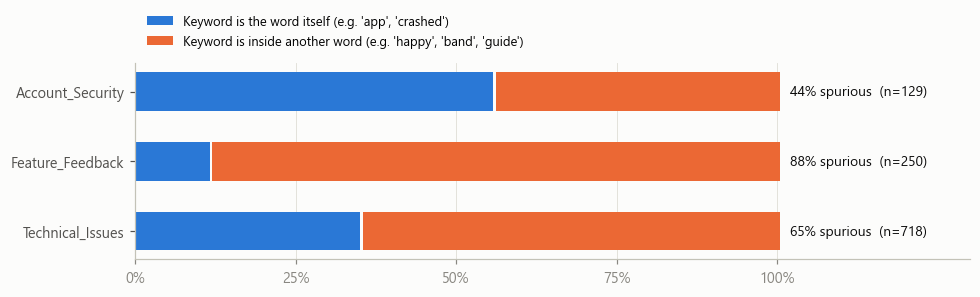

In [24]:
expl = pd.DataFrame([rules.explain(t) for t in data.post_text], columns=["rule_label", "keyword", "token", "whole_word"])
expl["label"] = data.topic_category.values
fired = expl[expl.keyword.notna()].astype({"whole_word": bool})
share = fired.groupby("label").whole_word.agg(["mean", "size"]).rename(columns={"mean": "whole_word_share", "size": "n"})
share["inside_other_word_share"] = 1 - share.whole_word_share
top_tokens = {lab: g[~g.whole_word].token.value_counts().head(8).to_dict() for lab, g in fired.groupby("label")}
METRICS["topic"]["whole_word_share"] = share.round(4).to_dict("index")
METRICS["topic"]["top_inside_word_triggers"] = top_tokens
display(share.round(3))
for lab, toks in top_tokens.items():
    print(lab, "->", toks)

share_plot = share.reindex(["Technical_Issues", "Feature_Feedback", "Account_Security"])
fig, ax = plt.subplots(figsize=(9, 2.8))
y = np.arange(len(share_plot))
ax.barh(y, share_plot.whole_word_share, color=S1, height=0.55, label="Keyword is the word itself (e.g. 'app', 'crashed')")
ax.barh(y, share_plot.inside_other_word_share, left=share_plot.whole_word_share + 0.004, color=S2, height=0.55,
        label="Keyword is inside another word (e.g. 'happy', 'band', 'guide')")
for yi, (lab, row) in zip(y, share_plot.iterrows()):
    ax.text(1.02, yi, f"{row.inside_other_word_share:.0%} spurious  (n={int(row.n)})", va="center", fontsize=9, color=INK)
ax.set_yticks(y, share_plot.index)
ax.set_xlim(0, 1.3); ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.02), ncol=1, fontsize=8.5)
ax.grid(axis="y", visible=False)
fig.tight_layout()
save(fig, "topic_substring_triggers")

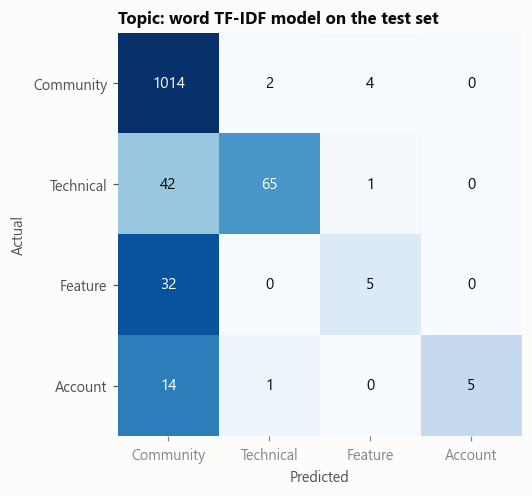

In [25]:
pw = topic_fitted["LogReg (word TF-IDF)"].predict(test.post_text)
cmt = confusion_matrix(test.topic_category, pw, labels=TOPICS)
cmtn = cmt / cmt.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(6.2, 4.6))
ax.imshow(cmtn, cmap="Blues", vmin=0, vmax=1)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{cmt[i, j]}", ha="center", va="center", fontsize=10, color="white" if cmtn[i, j] > 0.5 else INK)
short = ["Community", "Technical", "Feature", "Account"]
ax.set_xticks(range(4), short); ax.set_yticks(range(4), short)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.grid(False)
ax.set_title("Topic: word TF-IDF model on the test set")
for sp in ax.spines.values():
    sp.set_visible(False)
fig.tight_layout()
save(fig, "topic_confusion_word_model")
METRICS["topic"]["word_model_confusion"] = cmt.tolist()

**What this means.** A handful of substrings, checked in a fixed order, reproduce the topic labels exactly. Most Account_Security and Feature_Feedback labels were triggered by the keyword appearing *inside an unrelated word* ("band" contains "ban", "guide" contains "ui"), so "Happy Friday!" is labelled a technical issue. A word model cannot learn this because "happy" and "app" are different tokens; a character n-gram model can, and the rules themselves are perfect. The topic labels therefore describe spelling, not meaning. The Social Engine should not route posts on them; they need relabelling before a topic model is worth training.

## 10. Save models and outputs

In [26]:
joblib.dump(fitted["LogReg (word+char)"], MODEL / "Entropy_sentiment_tfidf_logreg.pkl")
joblib.dump(emb_lr, MODEL / "Entropy_sentiment_embedding_logreg.pkl")
joblib.dump(topic_fitted["LogReg (char 2-6 n-grams)"], MODEL / "Entropy_topic_char_logreg.pkl")
(MODEL / "Entropy_topic_rules.json").write_text(json.dumps(METRICS["topic"]["rules"], indent=2), encoding="utf-8")

uses_ft = SELECTED.startswith("Fine-tuned") or (SELECTED == "Weighted ensemble" and best_w["minilm_finetuned"] > 0)
if SELECTED == "Weighted ensemble":
    weights = best_w
elif SELECTED.startswith("Fine-tuned"):
    weights = {"tfidf_logreg": 0.0, "embedding_logreg": 0.0, "minilm_finetuned": 1.0}
elif SELECTED == "MiniLM embeddings + LogReg":
    weights = {"tfidf_logreg": 0.0, "embedding_logreg": 1.0, "minilm_finetuned": 0.0}
else:
    weights = {"tfidf_logreg": 1.0, "embedding_logreg": 0.0, "minilm_finetuned": 0.0}
ft_seeds = [best_seed] if "best seed" in SELECTED else SEEDS
ft_dirs = []
if uses_ft:
    for s in ft_seeds:
        d = f"Entropy_minilm_sentiment_seed{s}"
        FT[s]["model"].half().save_pretrained(MODEL / d, safe_serialization=True)
        FT[s]["tok"].save_pretrained(MODEL / d)
        FT[s]["model"].float()
        ft_dirs.append(d)

components = [
    {"name": "tfidf_logreg", "kind": "sklearn", "weight": weights["tfidf_logreg"],
     "file": "Entropy_sentiment_tfidf_logreg.pkl"},
    {"name": "embedding_logreg", "kind": "embedding", "weight": weights["embedding_logreg"],
     "file": "Entropy_sentiment_embedding_logreg.pkl", "embedder": MINILM},
    {"name": "minilm_finetuned", "kind": "transformer", "weight": weights["minilm_finetuned"],
     "dirs": ft_dirs, "cased": False, "max_len": MAX_LEN},
]
config = {"selected_model": SELECTED, "labels": LABELS, "components": components,
          "validation_macro_f1": round(float(res.loc[SELECTED, "val_macro_f1"]), 4),
          "test_macro_f1": METRICS["final"]["macro_f1"]}
(MODEL / "Entropy_sentiment_model.json").write_text(json.dumps(config, indent=2), encoding="utf-8")

out_pred = test[["text_id", "post_text", "sentiment_label", "topic_category"]].copy()
out_pred["predicted_sentiment"] = final_pred
for i, lab in enumerate(LABELS):
    out_pred[f"p_{lab.lower()}"] = final_proba[:, i].round(4)
out_pred["rule_topic"] = rules.predict(test.post_text)
out_pred.to_csv(OUT / "Entropy_r2_test_predictions.csv", index=False)
(OUT / "Entropy_r2_metrics.json").write_text(json.dumps(METRICS, indent=2, default=lambda o: o.item() if hasattr(o, "item") else str(o)), encoding="utf-8")
for p_ in sorted(MODEL.rglob("*")):
    if p_.is_file():
        print(f"{p_.relative_to(ROOT)}  {p_.stat().st_size/1024:,.0f} KB")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 21.91it/s]


model\Entropy_minilm_sentiment_seed1234\config.json  1 KB
model\Entropy_minilm_sentiment_seed1234\model.safetensors  44,376 KB
model\Entropy_minilm_sentiment_seed1234\tokenizer.json  695 KB
model\Entropy_minilm_sentiment_seed1234\tokenizer_config.json  1 KB
model\Entropy_minilm_sentiment_seed42\config.json  1 KB
model\Entropy_minilm_sentiment_seed42\model.safetensors  44,376 KB
model\Entropy_minilm_sentiment_seed42\special_tokens_map.json  1 KB
model\Entropy_minilm_sentiment_seed42\tokenizer.json  695 KB
model\Entropy_minilm_sentiment_seed42\tokenizer_config.json  1 KB
model\Entropy_minilm_sentiment_seed42\vocab.txt  226 KB
model\Entropy_minilm_sentiment_seed7\config.json  1 KB
model\Entropy_minilm_sentiment_seed7\model.safetensors  44,376 KB
model\Entropy_minilm_sentiment_seed7\tokenizer.json  695 KB
model\Entropy_minilm_sentiment_seed7\tokenizer_config.json  1 KB
model\Entropy_r2_model_artifacts.zip  130,563 KB
model\Entropy_sentiment_embedding_logreg.pkl  10 KB
model\Entropy_sentime

## 11. Inference demo: the rebuilt semantic layer

Loads the saved files from disk (not the objects in memory) and classifies new posts.

In [27]:
engine = nu.SentimentEnsemble(MODEL)
new_posts = [
    "Absolutely loving the new update, the app finally feels fast!",
    "My account got hacked again and support is ignoring me",
    "Match starts at 7pm tomorrow at the national stadium",
    "not bad at all, honestly better than I expected",
    "Great, another Monday. Just what I needed...",
    "Happy Friday everyone!",
]
probs = engine.predict_proba(new_posts)
demo = pd.DataFrame({"post": new_posts, "sentiment": np.array(LABELS)[probs.argmax(1)], "confidence": probs.max(1).round(3)})
demo[["topic (dataset rules)", "rule keyword", "matched word"]] = [rules.explain(t)[:3] for t in new_posts]
check = engine.predict(test.post_text.head(200))
print("Reloaded model agrees with in-memory predictions on", f"{(check == final_pred[:200]).mean():.1%}", "of 200 test posts")
demo

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 3421.21it/s]


Reloaded model agrees with in-memory predictions on 100.0% of 200 test posts


,post,sentiment,confidence,topic (dataset rules),rule keyword,matched word
0,"Absolutely loving the new update, the app finally feels fast!",Positive,0.921,Technical_Issues,app,app
1,My account got hacked again and support is ignoring me,Negative,0.794,Account_Security,account,account
2,Match starts at 7pm tomorrow at the national stadium,Neutral,0.785,Community_Discussion,None,None
3,"not bad at all, honestly better than I expected",Positive,0.677,Community_Discussion,None,None
4,"Great, another Monday. Just what I needed...",Positive,0.818,Community_Discussion,None,None
5,Happy Friday everyone!,Positive,0.954,Technical_Issues,app,happy
